# Model 3: Transfer Learning with MobileNetV2

**Objective:** Train a classifier using a pre-trained MobileNetV2 base.

**Plan:**
1.  **Phase 1: Feature Extraction**
    * Load MobileNetV2 (pre-trained on ImageNet).
    * Freeze all base model layers.
    * Add a new, unfrozen classifier head.
    * Train *only* the new head using a normal learning rate (e.g., `1e-3`).
2.  **Phase 2: Fine-Tuning (Optional)**
    * Unfreeze the last few layers of the base model.
    * Train the *entire* model (unfrozen base layers + head) using a very low learning rate (e.g., `1e-5`).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import pandas as pd
from tqdm import tqdm
import sys
from pathlib import Path
import os
import numpy as np
import time

print("Libraries imported.")

Libraries imported.


In [2]:
# --- Path Setup ---
print(f"Current working dir: {os.getcwd()}")
project_root = Path(os.getcwd())

# If running from 'notebooks' folder, go one level up
if project_root.name == 'notebooks':
    project_root = project_root.parent

sys.path.append(str(project_root))
sys.path.append(str(project_root / 'src')) # src folder ko path mein add kiya
print(f"Project Root: {project_root}")

# --- Import Model 3 & PneumoniaDataset ---
try:
    from Models.model3 import Model3_MobileNet
    from data_preprocessing import PneumoniaDataset 
    print("Successfully imported Model3_MobileNet and PneumoniaDataset.")
except ImportError as e:
    print(f"ERROR: {e}")
    print("Ensure 'Models/model3.py' and 'src/data_preprocessing.py' exist.")

Current working dir: d:\Major\FedMedSeg\notebooks
Project Root: d:\Major\FedMedSeg
Successfully imported Model3_MobileNet and PneumoniaDataset.


In [3]:
# --- Configuration ---
PROCESSED_DIR = project_root / 'data' / 'processed'
TRAIN_CSV = PROCESSED_DIR / 'train_split.csv'
VAL_CSV = PROCESSED_DIR / 'val_split.csv'
MODEL_SAVE_PATH = project_root / 'models' / 'model_3_mobilenet_best.pth'

# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Phase 1 (Head Training)
EPOCHS_PHASE_1 = 15 # Transfer learning is fast
LR_PHASE_1 = 1e-3  # Normal LR for new head

# Phase 2 (Fine-Tuning)
EPOCHS_PHASE_2 = 10 # 5-10 epochs
LR_PHASE_2 = 1e-5  # Very low LR for fine-tuning

EARLY_STOP_PATIENCE = 5

print(f"Using device: {DEVICE}")
print(f"Model save path: {MODEL_SAVE_PATH}")

Using device: cuda
Model save path: d:\Major\FedMedSeg\models\model_3_mobilenet_best.pth


**Cell 5 (Code cell): DataLoaders & Weighted Loss**
*(Yeh cell zaroori hai. MobileNetV2 ImageNet pe train hua tha, isliye humein ImageNet waale 'Normalize' values use karne chahiye)*

In [4]:
# --- Data Transforms (Using ImageNet Stats) ---
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
}

# --- Create Datasets (using PneumoniaDataset) ---
train_dataset = PneumoniaDataset(csv_file=TRAIN_CSV, transform=data_transforms['train'])
val_dataset = PneumoniaDataset(csv_file=VAL_CSV, transform=data_transforms['val'])

# --- Create DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"DataLoaders created.")
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")

# --- Calculate Weighted Loss (Aapke Model 1 notebook se) ---
all_data_df = pd.concat([pd.read_csv(TRAIN_CSV), pd.read_csv(VAL_CSV)])
normal_count = (all_data_df['label'] == 0).sum()
pneumonia_count = (all_data_df['label'] == 1).sum()
pos_weight = torch.tensor(normal_count / pneumonia_count, dtype=torch.float32).to(DEVICE)
print(f"Imbalance ratio (Pneumonia:Normal) = {pneumonia_count/normal_count:.2f}:1")
print(f"Calculated 'pos_weight' for loss function: {pos_weight.item():.4f}")

DataLoaders created.
Training images: 4684
Validation images: 1172
Imbalance ratio (Pneumonia:Normal) = 2.70:1
Calculated 'pos_weight' for loss function: 0.3705


**Cell 6 (Code cell): Training Loop Function**
*(Yeh Model 1 waale notebook se copy-pasted hai, bas thoda clean kiya hai)*

In [5]:
# --- Training Loop Function ---

def run_training(model, train_loader, val_loader, criterion, optimizer, num_epochs, model_save_path, patience):
    """Function to run a full training and validation loop."""
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        # --- Training Phase ---
        model.train()
        train_loss = 0.0
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
        
        for inputs, labels in train_pbar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels) # squeeze() zaroori hai
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_pbar.set_postfix({"loss": loss.item()})
        
        avg_train_loss = train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
        
        with torch.no_grad():
            for inputs, labels in val_pbar:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs.squeeze(), labels)
                val_loss += loss.item()
                val_pbar.set_postfix({"loss": loss.item()})
        
        avg_val_loss = val_loss / len(val_loader)
        history['val_loss'].append(avg_val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # --- ModelCheckpoint & EarlyStopping ---
        if avg_val_loss < best_val_loss:
            print(f"  Val loss improved ({best_val_loss:.4f} -> {avg_val_loss:.4f}). Saving model...")
            torch.save(model.state_dict(), model_save_path)
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"  Val loss did not improve. Counter: {epochs_no_improve}/{patience}")
            
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break
            
    print(f"Training finished. Best model saved to {model_save_path}")
    return model, history

## Phase 1: Training the Classifier Head

Abhi sirf custom head (aakhiri layers) train ho rahi hai. Base model frozen hai.

In [6]:
# --- Phase 1: Initialize and Train ---
print("--- Starting Training Phase 1 (Frozen Base) ---")

model = Model3_MobileNet().to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer ko sirf trainable parameters (head) do
optimizer_phase1 = optim.Adam(model.custom_head.parameters(), lr=LR_PHASE_1)

# Train...
model, history1 = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_phase1,
    num_epochs=EPOCHS_PHASE_1,
    model_save_path=MODEL_SAVE_PATH,
    patience=EARLY_STOP_PATIENCE
)

--- Starting Training Phase 1 (Frozen Base) ---


Epoch 1/15 | Train Loss: 0.1839 | Val Loss: 0.1211
  Val loss improved (inf -> 0.1211). Saving model...


Epoch 2/15 | Train Loss: 0.1351 | Val Loss: 0.1661
  Val loss did not improve. Counter: 1/5


Epoch 3/15 | Train Loss: 0.1212 | Val Loss: 0.1129
  Val loss improved (0.1211 -> 0.1129). Saving model...


Epoch 4/15 | Train Loss: 0.1111 | Val Loss: 0.1068
  Val loss improved (0.1129 -> 0.1068). Saving model...


...

Epoch 11/15 | Train Loss: 0.0985 | Val Loss: 0.1035
  Val loss did not improve. Counter: 1/5


Epoch 12/15 | Train Loss: 0.1042 | Val Loss: 0.1021
  Val loss did not improve. Counter: 2/5


Epoch 13/15 | Train Loss: 0.0970 | Val Loss: 0.1032
  Val loss did not improve. Counter: 3/5


Epoch 14/15 | Train Loss: 0.1010 | Val Loss: 0.1095
  Val loss did not improve. Counter: 4/5


Epoch 15/15 | Train Loss: 0.0919 | Val Loss: 0.0975
  Val loss improved (0.1003 -> 0.0975). Saving model...
Training finished. Best model saved to d:\Major\FedMedSeg\models\model_3_mobilenet_best.pth


## Phase 2: Fine-Tuning (Unfreezing)

Ab hum best model ko load karenge, aakhiri 5 layers ko unfreeze karenge, aur bahut kam Learning Rate ke saath dobara train karenge.

In [7]:
# --- Phase 2: Unfreeze and Fine-Tune ---
print("\n--- Starting Training Phase 2 (Fine-Tuning) ---")

# Best model ko load karo (jo Phase 1 mein save hua tha)
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Aakhiri 5 feature blocks ko unfreeze karo
model.unfreeze_layers(5)

# Naya optimizer banao jo SABHI trainable parameters ko dekhega
# (unfrozen base layers + head)
# LR ko bahut kam rakho (1e-5) taaki pre-trained weights kharaab na hon
optimizer_phase2 = optim.Adam(model.parameters(), lr=LR_PHASE_2)

# Phir se train karo (5-10 epochs)
model, history2 = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_phase2,
    num_epochs=EPOCHS_PHASE_2,
    model_save_path=MODEL_SAVE_PATH, # Best model ko overwrite kar do
    patience=3 # Fine-tuning ke liye kam patience
)

print("--- Transfer Learning Complete ---")


--- Starting Training Phase 2 (Fine-Tuning) ---
Unfreezing last 5 feature blocks...
Total feature blocks: 19. Unfrozen 5 blocks.


Epoch 1/10 | Train Loss: 0.0857 | Val Loss: 0.0852
  Val loss improved (inf -> 0.0852). Saving model...


Epoch 2/10 | Train Loss: 0.0767 | Val Loss: 0.0830
  Val loss improved (0.0852 -> 0.0830). Saving model...


Epoch 3/10 | Train Loss: 0.0698 | Val Loss: 0.0785
  Val loss improved (0.0830 -> 0.0785). Saving model...


Epoch 4/10 | Train Loss: 0.0642 | Val Loss: 0.0781
  Val loss improved (0.0785 -> 0.0781). Saving model...


...

Epoch 6/10 | Train Loss: 0.0578 | Val Loss: 0.0731
  Val loss improved (0.0764 -> 0.0731). Saving model...


Epoch 7/10 | Train Loss: 0.0534 | Val Loss: 0.0723
  Val loss improved (0.0731 -> 0.0723). Saving model...


Epoch 8/10 | Train Loss: 0.0472 | Val Loss: 0.0735
  Val loss did not improve. Counter: 1/3


Epoch 9/10 | Train Loss: 0.0507 | Val Loss: 0.0769
  Val loss did not improve. Counter: 2/3


Epoch 10/10 | Train Loss: 0.0460 | Val Loss: 0.0735
  Val loss did not improve. Counter: 3/3
Early stopping triggered after 10 epochs.
Training finished. Best model saved to d:\Major\FedMedSeg\models\model_3_mobilenet_best.pth
--- Transfer Learning Complete ---


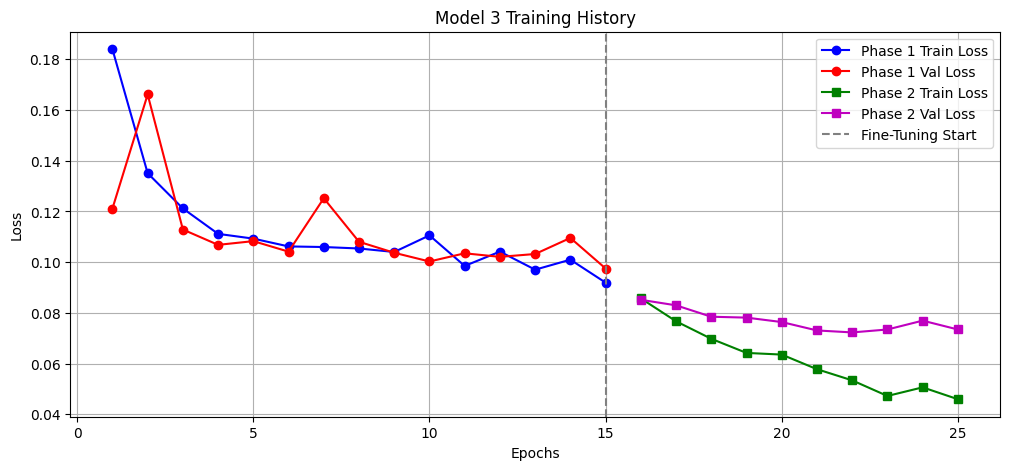

In [9]:
# %%
# --- Plot Training History ---
import matplotlib.pyplot as plt # <-- YEH LINE ADD KARO

plt.figure(figsize=(12, 5))
plt.title("Model 3 Training History")

# Phase 1
# 'history1' undefined na ho, isliye check karo
if 'history1' in locals():
    epochs1 = range(1, len(history1['train_loss']) + 1)
    plt.plot(epochs1, history1['train_loss'], 'bo-', label='Phase 1 Train Loss')
    plt.plot(epochs1, history1['val_loss'], 'ro-', label='Phase 1 Val Loss')
else:
    print("Warning: 'history1' not found. Skipping Phase 1 plot.")

# Phase 2
# 'history2' undefined na ho, isliye check karo
if 'history2' in locals():
    start_epoch = len(history1['train_loss']) if 'history1' in locals() else 0
    epochs2 = range(start_epoch + 1, start_epoch + len(history2['train_loss']) + 1)
    plt.plot(epochs2, history2['train_loss'], 'gs-', label='Phase 2 Train Loss')
    plt.plot(epochs2, history2['val_loss'], 'ms-', label='Phase 2 Val Loss')
else:
    print("Warning: 'history2' not found. Skipping Phase 2 plot.")


# Phase 1 aur 2 ke beech ek line
if 'history1' in locals():
    plt.axvline(x=len(history1['train_loss']), color='gray', linestyle='--', label='Fine-Tuning Start')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()